In [4]:
import os
import random
import glob
import cv2
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch
import torch.nn as nn
import torch.nn.functional as F
import json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import timm

import transformers
import PIL
import timm
from peft import LoraConfig, get_peft_model

# Разбор методов классификации

Рассмотрим ряд методов поиска логотипа на фото

* Сопоставление с шаблоном.

    Шаблон движется по исходному изображению, и на каждой позиции OpenCV вычисляет степень их схожести. В результате получается карта, на которой видны самые "горячие" точки.

  
    - Может как обнаруживать, так и классифицировать объекты. Для одного фото потребуется очень большое число сравнений.
    - Будет работать только для непрозрачных штампов
    - Очень сильное влияние оказывает фон
    - Отсутствие инвариантности к повороту, масштабированию.

    Потребуется делать огромное количество сравнений: число положений окна * число масштабов * число эталонов для логотипа * число логотипов

* Матчинг особых точек

      SIFT (Scale-Invariant Feature Transform) — алгоритм компьютерного зрения для обнаружения и описания уникальных ключевых точек на изображениях, разработанный Дэвидом Лоу в 1999 году. Осуществляется поиск "особых" точек на эталоне логотипа и на тестовом изображении. Похожесть определяется по числу совпавших точек.
    - Инвариантен к повороту, масштабированию, цвету.
    - Очень сильно зависит от фона
    - Плохо работает с изображениями, состоящими из гладких линий - алгоритму не за что зацепиться
    - Напротив при наличии, допустим, текста на логотипе - находит огромное число особых точек, что приводит к большому числу совпадений с тестовым изображением


Совпадений: 7


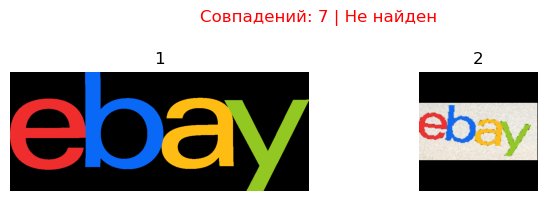

Совпадений: 14


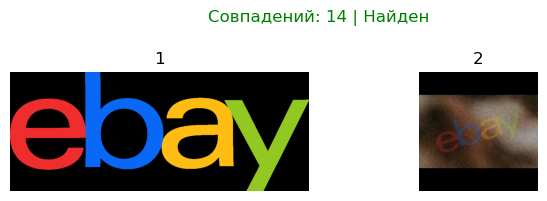

Совпадений: 18


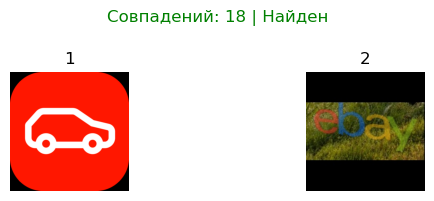

Совпадений: 2


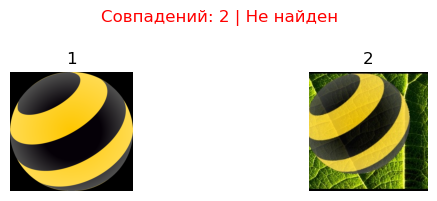

(False, 2)

In [ ]:
def compare_sift(img1_path, img2_path, min_matches=10, plot=True):
    img1 = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(img2_path, cv2.IMREAD_GRAYSCALE)

    sift = cv2.SIFT_create()
    kp1, desc1 = sift.detectAndCompute(img1, None)
    kp2, desc2 = sift.detectAndCompute(img2, None)

    bf = cv2.BFMatcher()
    matches = bf.knnMatch(desc1, desc2, k=2)

    good = [m for m, n in matches if m.distance < 0.75 * n.distance]
    found = len(good)>=min_matches
    print(f"Совпадений: {len(good)}")
    if plot:
        img1_color = cv2.cvtColor(cv2.imread(img1_path), cv2.COLOR_BGR2RGB)
        img2_color = cv2.cvtColor(cv2.imread(img2_path), cv2.COLOR_BGR2RGB)

        fig, axes = plt.subplots(1, 2, figsize=(7, 2))
        axes[0].imshow(img1_color)
        axes[0].set_title('1')
        axes[0].axis('off')

        axes[1].imshow(img2_color)
        axes[1].set_title('2')
        axes[1].axis('off')

        plt.suptitle(f"Совпадений: {len(good)} | {('Найден' if found else 'Не найден')}", 
                     color='green' if found else 'red', fontsize=12)
        plt.tight_layout()
        plt.show()
    return found, len(good)


compare_sift(r"./logos/ebay_1.png", r".\DATASETS\inference_generated_check_model_embs_test\ebay\000501.jpg")
compare_sift(r"./logos/ebay_1.png", r".\DATASETS\inference_generated_check_model_embs_test\ebay\000502.jpg")
compare_sift(r"./logos/auto-ru_2.png", r".\DATASETS\inference_generated_check_model_embs_test\ebay\000511.jpg")
compare_sift(r"./logos/beeline_1.png", r".\DATASETS\inference_generated_check_model_embs_test\beeline\000141.jpg")


В целом видно что работает очень нестабильно. Изменения порогового значения сработки ситуацию сильно не улучшает.

# Базовая модель

Модель предназначена для идентификации логотипов из некоторого списка на участке фотографии, выданной детектором.
Для обучения в качестве фона использовались фрагменты фотографий из датасета unsplash, поверх которых накладывались различные логотипы. В качестве аугментаций применялся поворот в пределах 20 градусов, прозрачность 0.4-1(где 1 - непрозрачный), небольшая дисторсия и удаления цвета.

In [ ]:
# base = os.getcwd()

class Config:
    MODEL_PATH = os.path.join(base, r'checkpoints\best_model.pth')
    REFERENCE_DB_PATH = os.path.join(base, r'reference_db_2\reference_db.npy')
    TEST_DATASET_PATH = os.path.join(base, r'DATASETS\inference_generated_dataset_test_01')
    
    IMG_SIZE = 224
    EMBEDDING_DIM = 512
    THRESHOLD = 0.5
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg = Config()

# Мод.
class LogoEmbedder(nn.Module):
    def __init__(self, embedding_dim=512):
        super().__init__()
        self.backbone = timm.create_model('efficientnet_b0', pretrained=False, num_classes=0)
        backbone_dim = self.backbone.num_features
        
        self.embedding = nn.Sequential(
            nn.Linear(backbone_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, embedding_dim),
            nn.LayerNorm(embedding_dim)
        )
    
    def forward(self, x):
        features = self.backbone(x)
        emb = self.embedding(features)
        return F.normalize(emb, p=2, dim=1)

def load_model(path):
    model = LogoEmbedder(embedding_dim=cfg.EMBEDDING_DIM)
    checkpoint = torch.load(path, map_location=cfg.DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(cfg.DEVICE)
    model.eval()
    return model

model = load_model(cfg.MODEL_PATH)

# Сохранённые эталончики
reference_db = np.load(cfg.REFERENCE_DB_PATH, allow_pickle=True).item()
print(f"Эталоны загружены: {len(reference_db)} брендов")

# Трансформации
transform = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

def get_embedding(image_path):
    """
    Получаем эмбеддинги фото
    """
    image = Image.open(image_path).convert('RGB')
    img_tensor = transform(image).unsqueeze(0).to(cfg.DEVICE)
    with torch.no_grad():
        emb = model(img_tensor).cpu().numpy()[0]
    return emb

def recognize_brand(query_emb, reference_db, threshold=cfg.THRESHOLD):
    """
    Сравниваем эмбеддинги фото с эмбеддингами в базе
    """
    best_brand = None
    best_score = -1
    
    for brand, ref_emb in reference_db.items():
        similarity = np.dot(query_emb, ref_emb)
        if similarity > best_score:
            best_score = similarity
            best_brand = brand
    
    if best_score >= threshold:
        return best_brand, best_score
    return None, best_score

# Загружаем тестовые изображения (с полными путями)
def load_test_images(test_path):
    """
    ПОдгружаем все файлы из папки с тестовыми изображениями
    """
    test_images = []

    for root, dirs, files in os.walk(test_path):
        for file in files:
            if file.endswith('.jpg'):
                full_path = os.path.join(root, file)
                brand_name = file[:-11]
                test_images.append({
                    'path': full_path,
                    'true_brand': brand_name,
                    'filename': file
                })
    
    print(f"Найдено {len(test_images)} изображегий")
    return test_images

test_images = load_test_images(cfg.TEST_DATASET_PATH)



В качестве эталоно взяты 55 изображений логотипов. Модель на них не обучалась. Некоторым брендам соответствуют более 1 логотипа. Но сравнение ведется именно по логотипам.

Запускаем


In [43]:
# Тестирование
results = []
correct = 0

for item in tqdm(test_images, desc="Тест"):
    emb = get_embedding(item['path'])
    predicted_brand, confidence = recognize_brand(emb, reference_db)
    
    its_correct = (predicted_brand == item['true_brand'])
    if its_correct:
        correct += 1
    
    results.append({
        'path': item['path'],
        'filename': item['filename'],
        'true_brand': item['true_brand'],
        'predicted_brand': predicted_brand,
        'confidence': confidence,
        'correct': its_correct
    })

# Статистика
accuracy = correct / (len(test_images)-20) * 100

print(f"Всего тестов: {len(test_images)}")
print(f"Правильно: {correct} ({accuracy:.1f}%)")


Тест: 100%|████████████████████████████████████████████████████████████████████████| 1120/1120 [00:18<00:00, 60.42it/s]

Всего тестов: 1120
Правильно: 799 (72.6%)


## Статистика по брендам

In [39]:
brand_stats = {}
for res in results:
    brand = res['true_brand']
    if brand not in brand_stats:
        brand_stats[brand] = {'correct': 0, 'total': 0}
    brand_stats[brand]['total'] += 1
    if res['correct']:
        brand_stats[brand]['correct'] += 1

for brand, stats in brand_stats.items():
    acc = stats['correct'] / stats['total'] * 100
    print(f"{brand}: {stats['correct']}/{stats['total']} = {acc:.1f}%")


aeroflot-bonus_1: 16/20 = 80.0%
airbnb_1: 15/20 = 75.0%
aliexpress-russia_1: 20/20 = 100.0%
argumenty-i-fakty_1: 14/20 = 70.0%
argumenty-i-fakty_2: 19/20 = 95.0%
auto-ru_1: 16/20 = 80.0%
auto-ru_2: 13/20 = 65.0%
beeline_1: 16/20 = 80.0%
belkart_1: 14/20 = 70.0%
belkart_2: 18/20 = 90.0%
bks_1: 18/20 = 90.0%
bks_2: 16/20 = 80.0%
booking-com_1: 17/20 = 85.0%
centralny-bank-rossii_1: 15/20 = 75.0%
che_1: 11/20 = 55.0%
che_2: 18/20 = 90.0%
chizhik_1: 16/20 = 80.0%
chizhik_2: 8/20 = 40.0%
citilink_1: 18/20 = 90.0%
citilink_2: 14/20 = 70.0%
dom-rf_1: 17/20 = 85.0%
domclick_1: 20/20 = 100.0%
domclick_2: 17/20 = 85.0%
drom_1: 15/20 = 75.0%
drom_2: 16/20 = 80.0%
ebay_1: 17/20 = 85.0%
empty: 0/20 = 0.0%
fix-price_1: 18/20 = 90.0%
fix-price_2: 19/20 = 95.0%
gazprombank_11: 15/20 = 75.0%
gazprombank_1: 13/20 = 65.0%
gaz_1: 9/20 = 45.0%
headhunter_1: 15/20 = 75.0%
kontur-diadoc_1: 13/20 = 65.0%
maz_1: 8/20 = 40.0%
ostrovok_1: 7/20 = 35.0%
ostrovok_2: 15/20 = 75.0%
ozon_1: 5/20 = 25.0%
ozon_2: 15/20 

## Анализ ошибок

Ряд брендов определяется с очень низкой точностью. Посмотрим на некоторые изображения с этими брендами

In [120]:
def find_similar_brands(image, top_k=3):
    """
    Находит наиболее похожие бренды
    """
    emb = get_embedding(image)
    similarityes = []
    for brand, ref_emb in reference_db.items():
        # Кос
        similarity = float(np.dot(emb, ref_emb))
        similarityes.append({
            'brand': brand,
            'similarity': similarity
        })
    similarityes.sort(key=lambda x: x['similarity'], reverse=True)
    return similarityes[:top_k]



def show_results(brand, num_pics=6):
    fig, axes = plt.subplots(1, num_pics, figsize=(15, 5))
    brand_pics = [res for res in results if res['true_brand'] == brand]
    random_pics = random.sample(brand_pics, min(num_pics, len(brand_pics)))
    for i, result in enumerate(random_pics):
        img = Image.open(result['path'])
        top = find_similar_brands(result['path'])
        
        axes[i].imshow(img)
        color = 'green' if result['correct'] else 'red'
        title = f"True: {result['true_brand']}\n Pred: {result['predicted_brand']}\n {result['confidence']:.2f}"
        axes[i].set_title(title, color=color, fontsize=10)
        print(f'_____{i}________')
        for position in top:
            print(position['brand'], position['similarity'])


_____0________
yandex-arenda_2 0.8413783311843872
yandex-travel_2 0.8242031931877136
yandex-ispolniteli_2 0.7699779272079468
_____1________
yandex-arenda_2 0.8789043426513672
yandex-travel_2 0.859533965587616
yandex-travel_1 0.8492854833602905
_____2________
yandex-travel_2 0.8915125131607056
yandex-arenda_2 0.8483537435531616
yandex-travel_1 0.8321725726127625
_____3________
yandex-travel_2 0.8882776498794556
yandex-arenda_2 0.834536075592041
yandex-travel_1 0.8107278347015381
_____4________
yandex-travel_2 0.8916475176811218
yandex-travel_1 0.852247953414917
yandex-arenda_2 0.8448485732078552
_____5________
yandex-travel_1 0.8529471158981323
yandex-arenda_2 0.8443492650985718
yandex-travel_2 0.8385140895843506


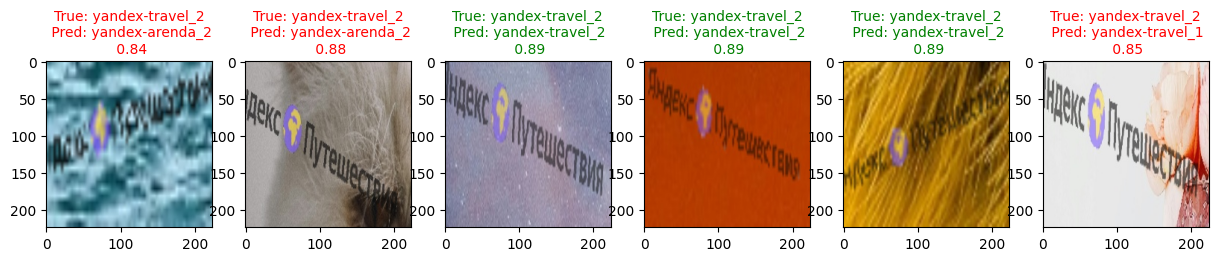

In [112]:
show_results('yandex-travel_2')

Эти бренды визуально действительно похожи и имеют структуру {яндекс}-лого-текст

_____0________
auto-ru_1 0.5157554149627686
ozon_1 0.47239938378334045
maz_1 0.35793811082839966
_____1________
ozon_1 0.5892879962921143
ozon_2 0.5073918104171753
yandex-arenda_1 0.5032278895378113
_____2________
ozon_1 0.7217347621917725
ebay_1 0.5659816861152649
ozon_2 0.5300244092941284
_____3________
fix-price_1 0.6571205258369446
bks_1 0.6442662477493286
ozon_1 0.6292812824249268
_____4________
yandex-arenda_1 0.6399821639060974
youla_2 0.6376051902770996
chizhik_1 0.6042604446411133
_____5________
gazprombank_11 0.611798882484436
petrovich_1 0.5728709697723389
ostrovok_2 0.5704339742660522


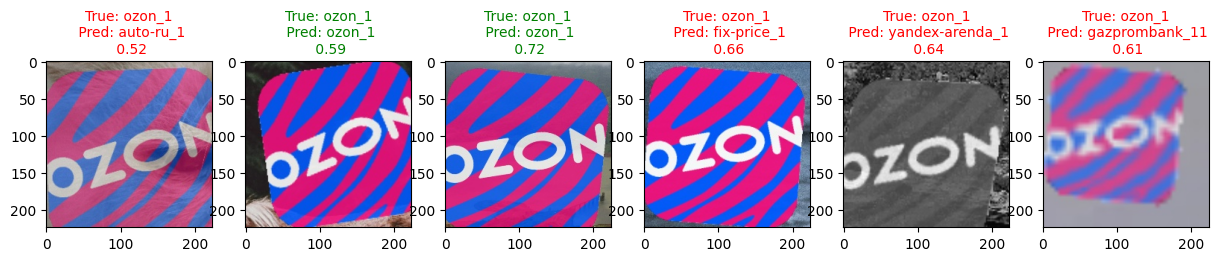

In [113]:
show_results('ozon_1')

Предсказание верного логотипа часто в тройке, однако уверенность очень низкая.

_____0________
petrovich_1 0.737906813621521
gaz_1 0.6760352253913879
playboy_2 0.6580101251602173
_____1________
chizhik_2 0.7889125347137451
playboy_2 0.6732131242752075
beeline_1 0.6446875333786011
_____2________
playboy_2 0.810909628868103
chizhik_2 0.7910451889038086
utkonos_1 0.7169135212898254
_____3________
chizhik_2 0.7851856350898743
chizhik_1 0.7589313983917236
playboy_2 0.704440712928772
_____4________
chizhik_2 0.8100658655166626
playboy_2 0.7620582580566406
chizhik_1 0.6789239645004272
_____5________
chizhik_1 0.7417314648628235
chizhik_2 0.6669554710388184
booking-com_1 0.6137701869010925


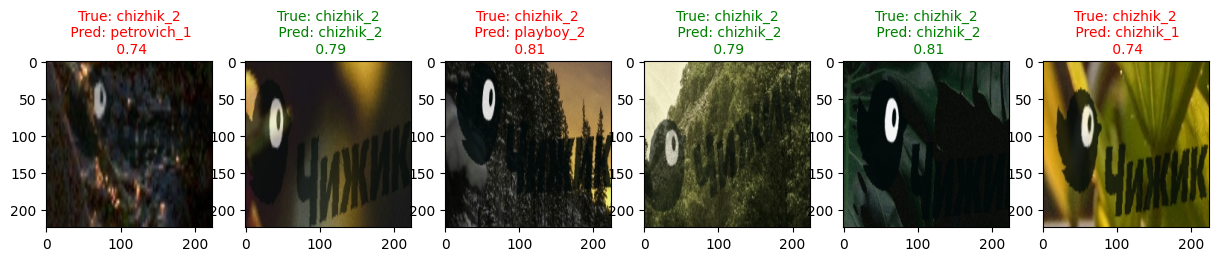

In [115]:
show_results('chizhik_2')

Визуально сложные для определения логотипа картинки. Видно что в ряде случае модель верно определяет бренд, но путает логотип, за счёт того что некоторые элементы на картинках совпадают

<img src="chizhik_1_000332.jpg" width="100">

_____0________
centralny-bank-rossii_1 0.6570755243301392
airbnb_1 0.617867112159729
citilink_1 0.5962965488433838
_____1________
playboy_1 0.7484544515609741
gaz_1 0.7403401732444763
centralny-bank-rossii_1 0.7202920913696289
_____2________
playboy_1 0.8499287366867065
gaz_1 0.7637935876846313
centralny-bank-rossii_1 0.6884559988975525
_____3________
beeline_1 0.7250632643699646
gazprombank_11 0.6895970106124878
gaz_1 0.6580216884613037
_____4________
petrovich_1 0.7775603532791138
playboy_1 0.6918522119522095
gaz_1 0.664956271648407


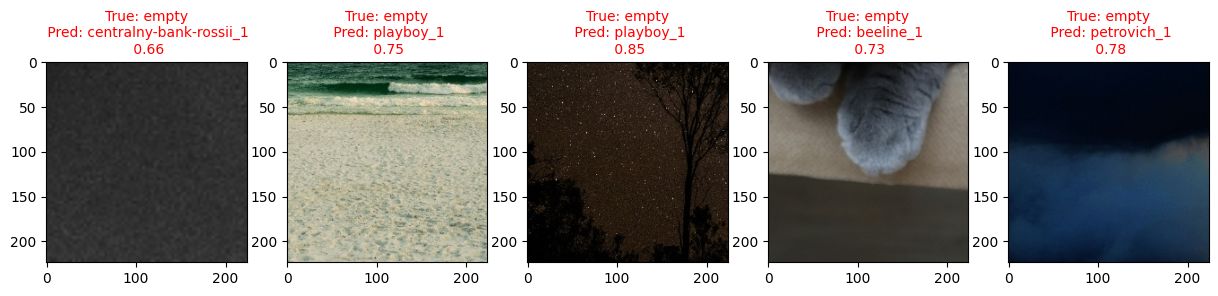

In [129]:
show_results('empty',5)

В то же время на пустых изображениях модель "нашла" логотипы, причем с достаточно большой степенью уверенности.

Наиболее уверенно выбранные логотипы на "пустой" картинке представляют собой тёмные изображения.
Возможно в качестве негативных вариантов при обучении модели подавалось мало картинок с чистым фоном без логотипа.

После нескольких итераций было принято решение использовать dinov2.

# DINO

In [81]:
base='.'
class Config:
    CLASSIFIER_PATH = r'.\dino_v2\dinov2_arcface_background_epoch40.pth'
    REFERENCE_DB_PATH = r'.\mean_work_embeddings_check_model.npy'
    TEST_DATASET_PATH = r'.\DATASETS\inference_generated_check_model_embs_test'
    CLASSIFIER_BACKBONE_NAME = 'vit_small_patch14_dinov2.lvd142m'
    IMG_SIZE = 224
    EMBEDDING_DIM = 512
    THRESHOLD = 0.5
    CLASSIFIER_PIC_SIZE_MAX=224
    CLASSIFIER_LORA_R = 16
    CLASSIFIER_LORA_ALPHA = 16
    CLASSIFIER_LORA_DROPOUT = 0.1
    CLASSIFIER_LORA_TARGET_MODULES = ['attn.qkv']
    CLASSIFIER_EMBEDDING_SIZE = 384

    IMAGE_MEAN = [0.485, 0.456, 0.406]
    IMAGE_STD = [0.229, 0.224, 0.225]
    
    
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config = Config()

In [100]:
class LogoClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        backbone = timm.create_model(config.CLASSIFIER_BACKBONE_NAME,
                                     pretrained=False,
                                     num_classes=0,
                                     img_size=config.CLASSIFIER_PIC_SIZE_MAX)

        lora_config = LoraConfig(
            r=config.CLASSIFIER_LORA_R,
            lora_alpha=config.CLASSIFIER_LORA_ALPHA,
            target_modules=config.CLASSIFIER_LORA_TARGET_MODULES,
            lora_dropout=config.CLASSIFIER_LORA_DROPOUT,
        )
        self.backbone = get_peft_model(backbone, lora_config)

        self.projection = nn.Sequential(
            nn.Linear(config.CLASSIFIER_EMBEDDING_SIZE, 512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 384),
        )

        checkpoint = torch.load(config.CLASSIFIER_PATH, map_location=self.device)
        self.load_state_dict(checkpoint, strict=False)
        self.to(self.device)
        self.eval()

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=config.IMAGE_MEAN, std=config.IMAGE_STD),
        ])

        checkpoint = torch.load(config.CLASSIFIER_PATH, map_location=self.device)
        self.load_state_dict(checkpoint, strict=False)
        self.to(self.device)
        self.eval()

    
    def get_embedding(self, image):
        """
        Возвращает нормализованный эмбеддинг
        Args:
            image (PIL.IMAGE): Изображение для получения эмбеддинга
        Returns:
            embedding (np.array): Полученный эмбеддинг
        """
        tensor = self.transform(image).unsqueeze(0)  # (1, 3, H, W)
        tensor = tensor.to(self.device)
        with torch.no_grad():
            features = self.backbone(tensor)
            embedding = self.projection(features)
            embedding = embedding / (torch.norm(embedding, dim=1, keepdim=True) + 1e-8)

        return embedding.squeeze().detach().cpu().numpy()


In [101]:
classifier=LogoClassifier()

C:\Users\Bamse\AppData\Local\Temp\ipykernel_15140\2467769741.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(config.CLASSIFIER_PATH, map_locatio

В тестовой выборке было значительно увеличено число "пустых" фото разных форм-факторов. До 400.

## Подбор оптимального порога срабатывания

In [223]:
embeddings_array = np.load('mean_work_embeddings_check_model.npy', allow_pickle=True)
with open('mean_work_embeddings_check_mode_map.json', 'r', encoding='utf-8') as f:
    idx_to_brand = json.load(f)
# {brand_name: embedding}
reference_db = {}
for idx, brand_name in idx_to_brand.items():
    idx_int = int(idx) 
    reference_db[brand_name] = embeddings_array[idx_int]

print(f"Всего эталонов: {len(reference_db)}")

def recognize_brand(test_embedding, reference_db, threshold=0.5):
    """
    Распознавание бренда
    
    Args:
        test_embedding: эмбеддинг тестового изображения
        reference_db: словарь {brand_name: embedding}
        threshold: порог уверенности (если ниже - возвращаем unknown)
    
    Returns:
        predicted_brand: название бренда или "unknown"
        confidence: максимальная уверенность
    """
    best_brand = None
    best_score = -1

    # самый похожий бренд
    for brand_name, ref_embedding in reference_db.items():
        similarity = np.dot(test_embedding, ref_embedding)
        if similarity > best_score:
            best_score = similarity
            best_brand = brand_name
    
    # Если ниже порога - unknown
    if best_score < threshold:
        return "unknown", best_score, best_brand
    else:
        return best_brand, best_score, best_brand

# тестовые изображения
test_images = []
test_dir = r".\DATASETS\inference_generated_check_model_embs_test"

for folder_name in os.listdir(test_dir):
    folder_path = os.path.join(test_dir, folder_name)
    if os.path.isdir(folder_path):
        is_empty = folder_name.lower().startswith('empty')
        
        for img_file in os.listdir(folder_path):
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                test_images.append({
                    'path': os.path.join(folder_path, img_file),
                    'filename': img_file,
                    'true_brand': 'unknown' if is_empty else folder_name,
                    'folder_name': folder_name
                })

regular_images = [img for img in test_images if img['true_brand'] != 'unknown']
empty_images = [img for img in test_images if img['true_brand'] == 'unknown']
print(f"Обычные изображения (с брендами): {len(regular_images)}")
print(f"Пустые изображения (empty): {len(empty_images)}")

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8] 
print("Поиск лучшего порогоа")
accuracy_logo = []
accuracy_empty = []
for threshold in thresholds:
    correct = 0
    correct_regular = 0
    correct_empty = 0
    
    for item in test_images:
        image = Image.open(item['path']).convert('RGB')
        emb = classifier.get_embedding(image)
        predicted_brand, confidence, _ = recognize_brand(emb, reference_db, threshold)
        
        # Проверяем
        if predicted_brand == item['true_brand']:
            correct += 1
            if item['true_brand'] == 'unknown':
                correct_empty += 1
            else:
                correct_regular += 1
    
    acc = correct / len(test_images) * 100
    acc_regular = correct_regular / len(regular_images) * 100 if regular_images else 0
    acc_empty = correct_empty / len(empty_images) * 100 if empty_images else 0
    accuracy_logo.append(acc_regular)
    accuracy_empty.append(acc_empty)
    print(f"Порог: {threshold:.1f} -> Общая точность: {acc:.1f}% | По брендам: {acc_regular:.1f}% | Без лого: {acc_empty:.1f}%")

Всего эталонов: 55
Обычные изображения (с брендами): 1100
Пустые изображения (empty): 400
Поиск лучшего порогоа
Порог: 0.3 -> Общая точность: 95.9% | По брендам: 95.4% | Без лого: 97.2%
Порог: 0.4 -> Общая точность: 95.3% | По брендам: 93.8% | Без лого: 99.5%
Порог: 0.5 -> Общая точность: 93.7% | По брендам: 91.4% | Без лого: 100.0%
Порог: 0.6 -> Общая точность: 90.7% | По брендам: 87.4% | Без лого: 100.0%
Порог: 0.7 -> Общая точность: 86.2% | По брендам: 81.2% | Без лого: 100.0%
Порог: 0.8 -> Общая точность: 78.7% | По брендам: 71.0% | Без лого: 100.0%


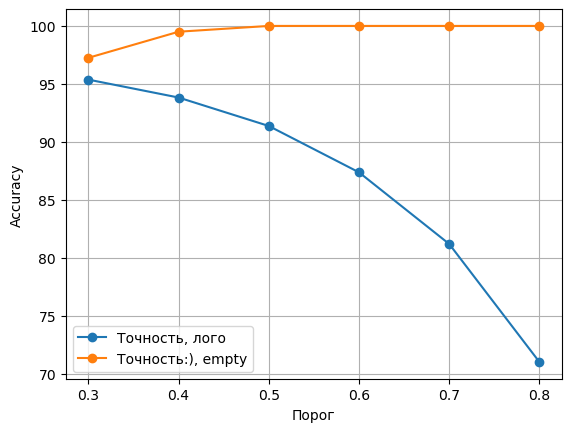

In [225]:
plt.plot(thresholds, accuracy_logo, label='Точность, лого', marker='o')
plt.plot(thresholds, accuracy_empty, label='Точность:), empty', marker='o')
plt.xlabel('Порог')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Рассмотрим порог 0.5. Ложных срабатываний при таком пороге практически нет, что важно при проверке большого числа поступающих фотографий, большинство из которых не содержат искомых логотипов. Данный порог стоит корректировать в зависимости от результатов работы детектора.

## Статистика по брендам

In [229]:
threshold = 0.5
print(f'Порог = {threshold}')
results = []
correct = 0
correct_regular = 0
correct_empty = 0

for item in tqdm(test_images, desc="Тестирование"):
    image = Image.open(item['path']).convert('RGB')
    emb = classifier.get_embedding(image)
    predicted_brand, confidence, closest_brand = recognize_brand(emb, reference_db, best_threshold)
    
    is_correct = (predicted_brand == item['true_brand'])
    if is_correct:
        correct += 1
        if item['true_brand'] == 'unknown':
            correct_empty += 1
        else:
            correct_regular += 1
    
    results.append({
        'path': item['path'],
        'filename': item['filename'],
        'folder_name': item['folder_name'],
        'true_brand': item['true_brand'],
        'predicted_brand': predicted_brand,
        'confidence': confidence,
        'correct': is_correct,
        'closest_brand': closest_brand
    })

acc_total = correct / len(test_images) * 100
acc_regular = correct_regular / len(regular_images) * 100 if regular_images else 0
acc_empty = correct_empty / len(empty_images) * 100 if empty_images else 0


print(f"{'_' * 40}")
print(f"Всего тестов: {len(test_images)}")
print(f"Правильно:    {correct} из {len(test_images)} ({acc_total:.1f}%)")
print()
print(f"С лого:    {correct_regular}/{len(regular_images)} ({acc_regular:.1f}%)")
print(f"Без лого:  {correct_empty}/{len(empty_images)} ({acc_empty:.1f}%)")

false_positives = [r for r in results if r['true_brand'] == 'unknown' and r['predicted_brand'] != 'unknown']

print(f"Статистика по брендам")
brand_stats = {}
for r in results:
    if r['true_brand'] == 'unknown':
        continue
    brand = r['true_brand']
    if brand not in brand_stats:
        brand_stats[brand] = {'total': 0, 'correct': 0}
    brand_stats[brand]['total'] += 1
    if r['correct']:
        brand_stats[brand]['correct'] += 1

for brand, stats in sorted(brand_stats.items()):
    acc = stats['correct'] / stats['total'] * 100
    print(f"{brand:30s}: {stats['correct']:3d}/{stats['total']:3d} ({acc:5.1f}%)")

Порог = 0.5


Тестирование: 100%|████████████████████████████████████████████████████████████████| 1500/1500 [00:21<00:00, 69.66it/s]

________________________________________
Всего тестов: 1500
Правильно:    1405 из 1500 (93.7%)

С лого:    1005/1100 (91.4%)
Без лого:  400/400 (100.0%)
Статистика по брендам
aeroflot-bonus                :  18/ 20 ( 90.0%)
airbnb                        :  20/ 20 (100.0%)
aliexpress-russia             :  18/ 20 ( 90.0%)
argumenty-i-fakty1            :  20/ 20 (100.0%)
argumenty-i-fakty2            :  17/ 20 ( 85.0%)
auto-ru1                      :  17/ 20 ( 85.0%)
auto-ru2                      :  20/ 20 (100.0%)
beeline                       :  20/ 20 (100.0%)
belkart1                      :  18/ 20 ( 90.0%)
belkart2                      :  19/ 20 ( 95.0%)
bks1                          :  20/ 20 (100.0%)
bks2                          :  15/ 20 ( 75.0%)
booking-com                   :  19/ 20 ( 95.0%)
centralny-bank-rossii         :  16/ 20 ( 80.0%)
che1                          :  19/ 20 ( 95.0%)
che2                          :  18/ 20 ( 90.0%)
chizhik1                      :  20/ 20 (

## Анализ ошибок

Посмотрим на некоторые "проблемные" логотипы.

In [187]:
def find_similar_brands(image_path, top_k=3):
    image = Image.open(image_path).convert('RGB')
    emb_norm = classifier.get_embedding(image)
        
    similarities = []
    for brand, ref_norm in reference_db.items():
        sim = float(np.dot(emb_norm, ref_norm))
        similarities.append({'brand': brand, 'similarity': sim})
    
    similarities.sort(key=lambda x: x['similarity'], reverse=True)
    return similarities[:top_k]

def show_results(brand):
    num_pics=6
    brand_pics = [r for r in results if r['true_brand'] == brand]
    random_pics = random.sample(brand_pics, min(num_pics, len(brand_pics)))

    nrows = 2
    ncols = 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
    axes = axes.flatten()
    
    for i, res in enumerate(random_pics):
        img = Image.open(res['path'])
        top = find_similar_brands(res['path'])
        
        axes[i].imshow(img)
        axes[i].axis('off')
        color = 'green' if res['correct'] else 'red'
        axes[i].set_title(f"True: {res['true_brand']}\nPred: {res['predicted_brand']}\n{res['confidence']:.3f}", 
                         color=color, fontsize=10)
        
        print(f"\n--- {res['filename']} ---")
        for p in top:
            print(f"  {p['brand']}: {p['similarity']:.4f}")
      
    plt.tight_layout()
    plt.show()


--- 001456.jpg ---
  yandex-travel2: 0.6427
  yandex-arenda2: 0.5534
  ostrovok2: 0.2058

--- 001459.jpg ---
  yandex-travel2: 0.7328
  yandex-arenda2: 0.4801
  yandex-ispolniteli2: 0.4351

--- 001446.jpg ---
  yandex-travel2: 0.8215
  yandex-arenda2: 0.5830
  yandex-ispolniteli2: 0.3194

--- 001458.jpg ---
  yandex-travel2: 0.4722
  youla1: 0.3684
  yandex-arenda2: 0.3096

--- 001442.jpg ---
  yandex-travel2: 0.4815
  youla1: 0.3036
  utkonos: 0.2550

--- 001445.jpg ---
  yandex-travel2: 0.7179
  yandex-arenda2: 0.6258
  yandex-ispolniteli2: 0.5520


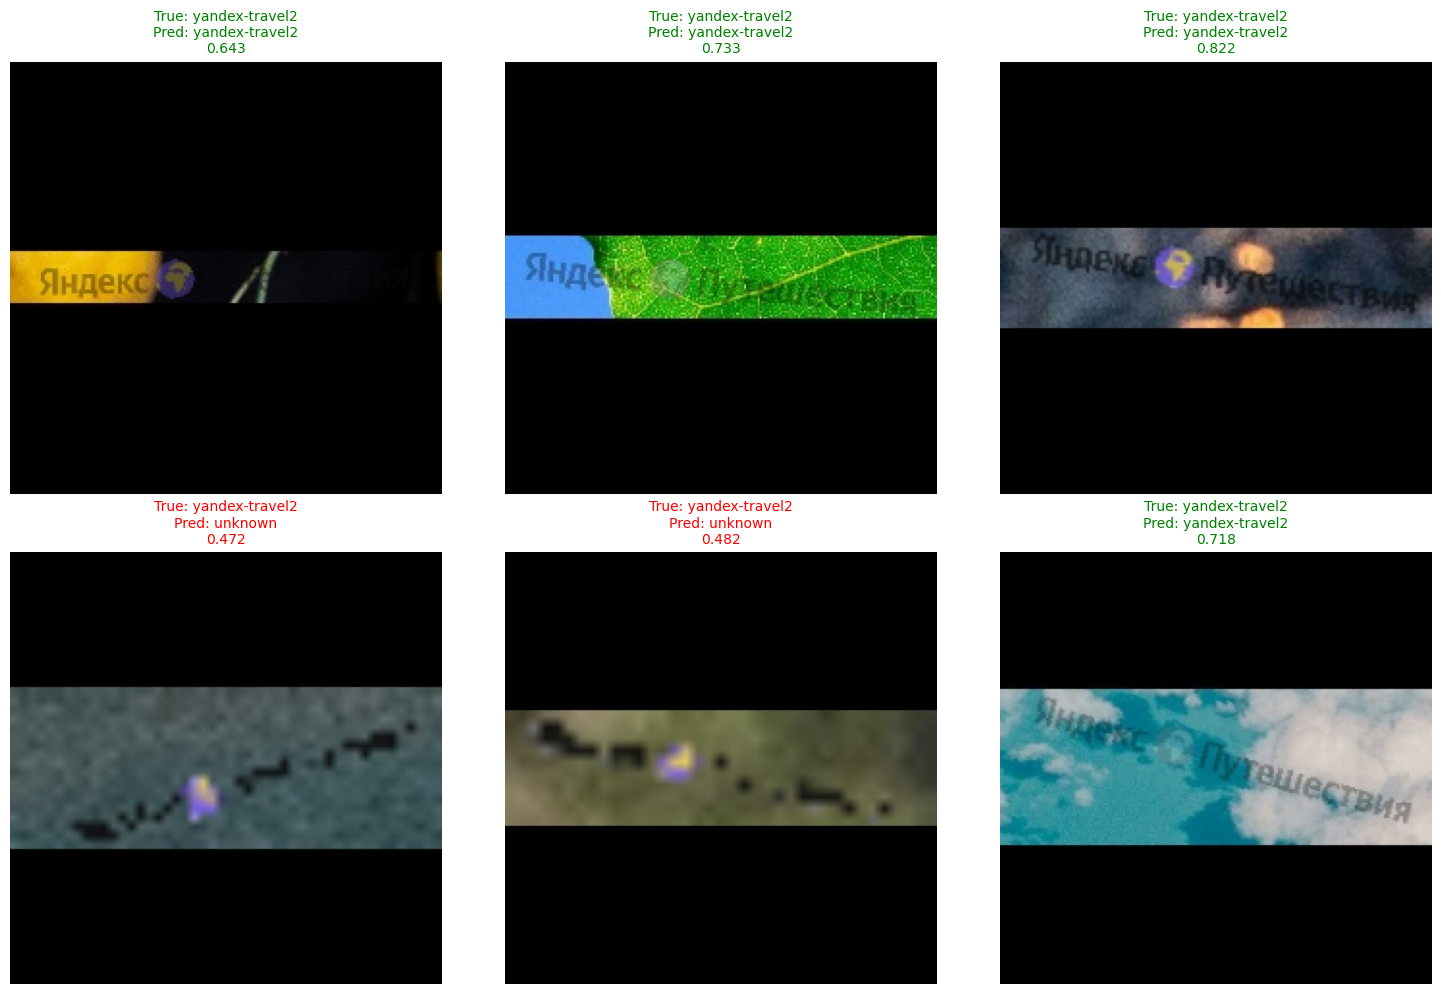

In [179]:
show_results('yandex-travel2')

* ошибки появляются на действительно почти не читаемых изображениях
* наиболее похожими вновь являются логотипы имеющие аналогичную структуру и элементы.


--- 001234.jpg ---
  gazprombank1: 0.1044
  domclick2: 0.0883
  belkart2: 0.0769

--- 001227.jpg ---
  playboy2: 0.4639
  fix-price1: 0.2166
  chizhik1: 0.1548

--- 001232.jpg ---
  playboy2: 0.6169
  chizhik2: 0.2932
  youla2: 0.2658

--- 001224.jpg ---
  playboy2: 0.5856
  chizhik2: 0.4086
  yandex-ispolniteli2: 0.2069

--- 001226.jpg ---
  playboy2: 0.6495
  vseinstrumenti1: 0.2536
  yandex-nedvizhimost: 0.2457

--- 001236.jpg ---
  playboy1: 0.2569
  beeline: 0.2095
  yandex-travel2: 0.1851


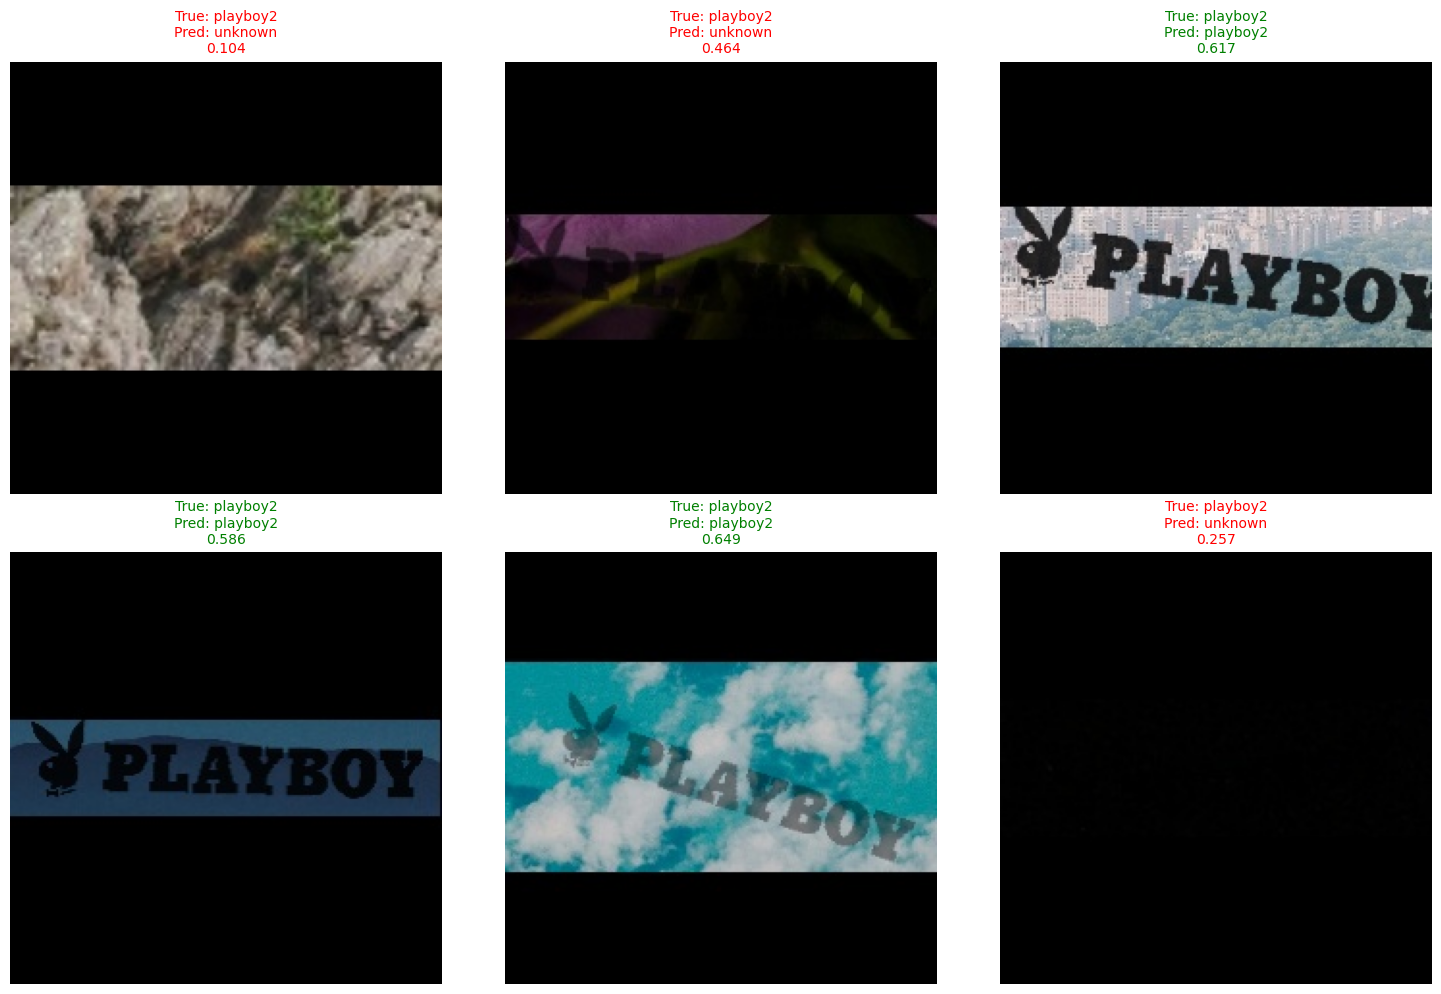

In [216]:
show_results('playboy2')

В примере с прошлым брендом ошибки были вызваны низким разрешением изображения, здесь же основная проблема в очень низком контрасте между темным изображением и темной вотермаркой.


--- 000396.jpg ---
  citilink2: 0.6143
  gazprombank1: 0.3538
  aeroflot-bonus: 0.1802

--- 000391.jpg ---
  citilink2: 0.6610
  gazprombank1: 0.3282
  aeroflot-bonus: 0.2352

--- 000397.jpg ---
  belkart2: 0.3373
  yandex-arenda2: 0.3100
  airbnb: 0.2574

--- 000381.jpg ---
  citilink2: 0.6581
  bks2: 0.3001
  ozon2: 0.1546

--- 000386.jpg ---
  citilink2: 0.4991
  ebay: 0.2375
  yandex-arenda2: 0.2272

--- 000389.jpg ---
  citilink2: 0.5824
  yandex-ispolniteli1: 0.2286
  ebay: 0.2033


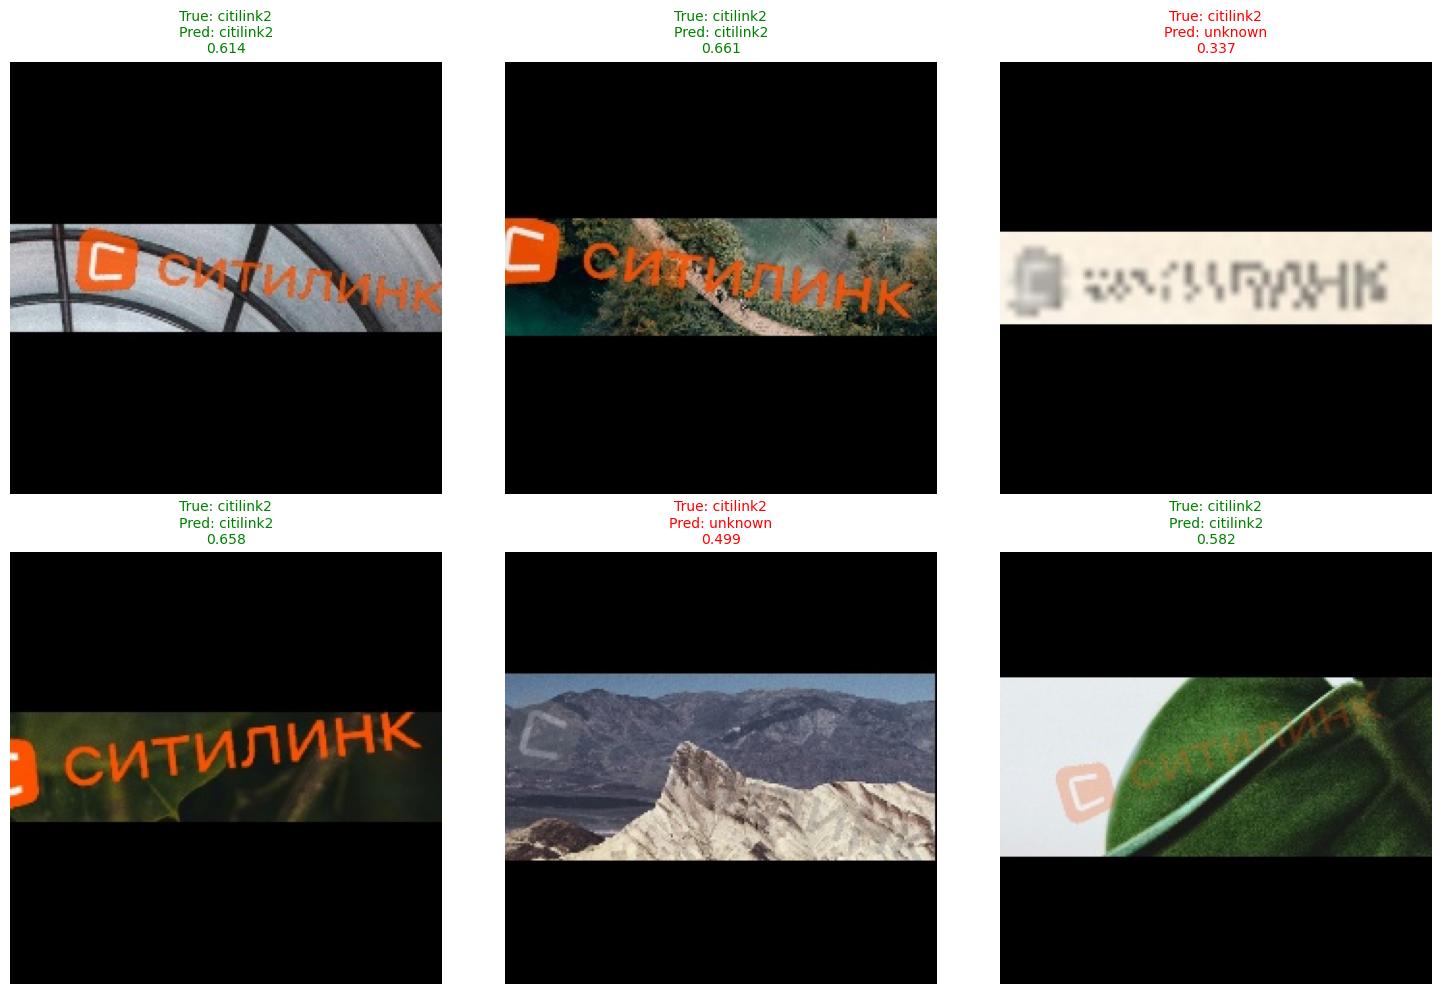

In [218]:
show_results('citilink2')

Результат аналогичен

## Выводы

* Модель хорошо показывает себя на большинстве логотипов
* Весомая доля ошибок вызвана объективно низким контрастом вотермарки с фоном или низким разрешением в тестовом примере
* Основную проблему представляют логотипы имеющие вид изображение + текст. Для поиска подобных, вероятно, более применимы методы OCR.
* Учитывая малое значение ложных срабатываний стоит рассматривать вариант использования нескольких эталонов логотипов вместо одного